# Customer Churn Analysis using SQL & Python

## Project Overview
Customer churn can directly affect recurring revenue and customer growth. In this project, I combine customer, subscription, and support data to understand churn patterns and identify areas that may need attention.

The database work is done with MySQL through XAMPP, while Python is used for cleaning, feature engineering, analysis, and visualization.

## 1. Objectives
- Calculate churn and retention rates
- Compare churn across subscription plans and locations
- Analyze tenure and monthly charges
- Examine support escalations and churn
- Group customers using the available churn score
- Estimate monthly charges associated with churned customers

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
from sqlalchemy import create_engine


## 2. MySQL / XAMPP Connection

Start MySQL in XAMPP before running this section. Change the credentials if your local MySQL setup is different.

In [15]:
MYSQL_HOST = 'localhost'
MYSQL_USER = 'root'
MYSQL_PASSWORD = ''
DB_NAME = 'customer_churn'

server_conn = mysql.connector.connect(host=MYSQL_HOST, user=MYSQL_USER, password=MYSQL_PASSWORD)
server_cursor = server_conn.cursor()
server_cursor.execute(f'CREATE DATABASE IF NOT EXISTS {DB_NAME}')
server_cursor.close()
server_conn.close()

engine = create_engine(f'mysql+mysqlconnector://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/{DB_NAME}')
print('MySQL connection ready.')


MySQL connection ready.


## 3. Load the Source Data

In [16]:
file_path = '../data/customer_churn_data_raw.xlsx'

df_customer = pd.read_excel(file_path, sheet_name='db_customer')
df_subscription = pd.read_excel(file_path, sheet_name='db_subscription')
df_support = pd.read_excel(file_path, sheet_name='db_support')

print(df_customer.shape, df_subscription.shape, df_support.shape)


(1000, 8) (1000, 11) (206, 6)


## 4. Data Cleaning

In [17]:
df_customer = df_customer.rename(columns={'name': 'customer_name'})
df_customer = df_customer.drop(columns=['interests', 'pincode'])
df_customer['dob'] = pd.to_datetime(df_customer['dob'], errors='coerce')
df_customer['gender'] = df_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})

state_country = {
    'Maharashtra': 'India', 'Karnataka': 'India', 'Delhi': 'India',
    'Nagaland': 'India', 'Meghalaya': 'India', 'Rajasthan': 'India',
    'Telangana': 'India', 'Uttar Pradesh': 'India', 'Kathmandu': 'Nepal'
}
df_customer['country'] = df_customer['country'].fillna(df_customer['state'].map(state_country))

for col in ['subscription_start_date', 'renewal_date', 'cancellation_date']:
    df_subscription[col] = pd.to_datetime(df_subscription[col], errors='coerce')

df_support = df_support.drop(columns=['col_1', 'comment'])
df_support['complaint_date'] = pd.to_datetime(df_support['complaint_date'], errors='coerce')

print('Customer rows:', len(df_customer))
print('Subscription rows:', len(df_subscription))
print('Support rows:', len(df_support))


Customer rows: 1000
Subscription rows: 1000
Support rows: 206


## 5. Load Cleaned Tables into MySQL

In [18]:
df_customer.to_sql('db_customer', con=engine, if_exists='replace', index=False)
df_subscription.to_sql('db_subscription', con=engine, if_exists='replace', index=False)
df_support.to_sql('db_support', con=engine, if_exists='replace', index=False)
print('Tables loaded into MySQL.')


Tables loaded into MySQL.


## 6. Feature Engineering and Data Integration

In [19]:
df_subscription['churn_flag'] = df_subscription['cancellation_date'].notna().astype(int)

complaint_count = (
    df_support.groupby('customerid').size().rename('complaint_count').reset_index()
)

latest_support = (
    df_support.sort_values('complaint_date')
    .drop_duplicates('customerid', keep='last')
)

df = (
    df_subscription
    .merge(df_customer, on='customerid', how='left')
    .merge(latest_support[['customerid', 'escalations', 'csat_score']], on='customerid', how='left')
    .merge(complaint_count, on='customerid', how='left')
)

df['complaint_count'] = df['complaint_count'].fillna(0).astype(int)
df['churn_risk'] = pd.cut(df['churn_score'], [-1, 49, 69, 100], labels=['Low', 'Medium', 'High'])
df['tenure_days'] = (df['renewal_date'] - df['subscription_start_date']).dt.days

df.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,escalations,csat_score,complaint_count,churn_risk,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,0,Low,1461
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,N,60.0,2,High,1461
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,0,Low,1096
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,0,Low,2192
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,Y,20.0,1,High,365


## 7. SQL Analysis

In [20]:
query = """
SELECT plan_type, COUNT(*) AS customers,
       ROUND(AVG(cancellation_date IS NOT NULL) * 100, 2) AS churn_rate
FROM db_subscription
GROUP BY plan_type
ORDER BY churn_rate DESC;
"""

pd.read_sql(query, engine)


,plan_type,customers,churn_rate
0,Standard,415,31.81
1,Premium,247,31.17
2,Basic,338,26.33


## 8. Python Analysis

In [21]:
churn_rate = df['churn_flag'].mean() * 100
retention_rate = 100 - churn_rate
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
avg_tenure_months = df['tenure_days'].mean() / 30.44

print(f'Churn rate: {churn_rate:.2f}%')
print(f'Retention rate: {retention_rate:.2f}%')
print(f'Average tenure: {avg_tenure_months:.2f} months')
print(f'Monthly charges from churned customers: {revenue_at_risk:.2f}')

print('\nChurn by plan:')
print((df.groupby('plan_type')['churn_flag'].mean() * 100).sort_values(ascending=False))


Churn rate: 29.80%
Retention rate: 70.20%
Average tenure: 12.57 months
Monthly charges from churned customers: 4216.42

Churn by plan:
plan_type
Standard    31.807229
Premium     31.174089
Basic       26.331361
Name: churn_flag, dtype: float64


## 9. Visualizations

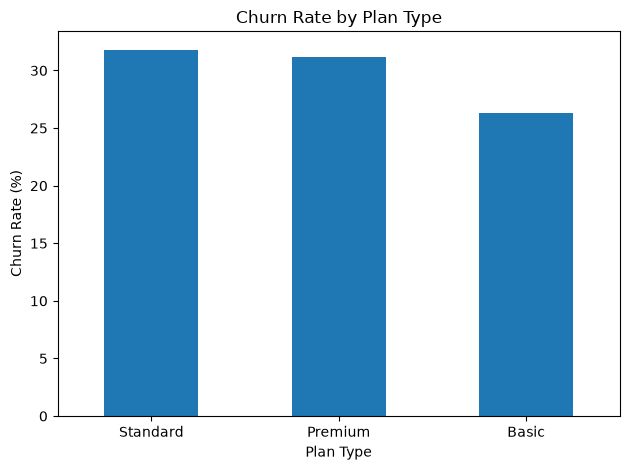

In [22]:
plan_churn = df.groupby('plan_type')['churn_flag'].mean().sort_values(ascending=False) * 100
plan_churn.plot(kind='bar', title='Churn Rate by Plan Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Plan Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


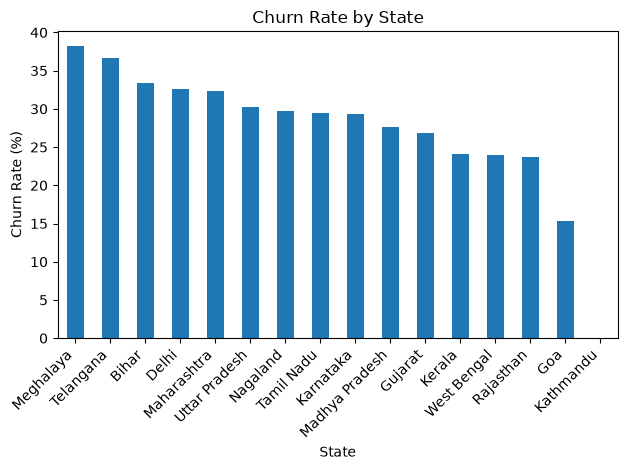

In [23]:
state_churn = df.groupby('state')['churn_flag'].mean().sort_values(ascending=False) * 100
state_churn.plot(kind='bar', title='Churn Rate by State')
plt.ylabel('Churn Rate (%)')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


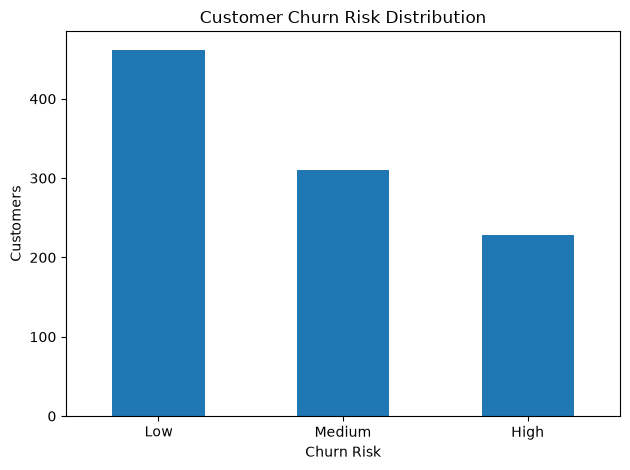

In [24]:
risk_counts = df['churn_risk'].value_counts().reindex(['Low', 'Medium', 'High'])
risk_counts.plot(kind='bar', title='Customer Churn Risk Distribution')
plt.ylabel('Customers')
plt.xlabel('Churn Risk')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


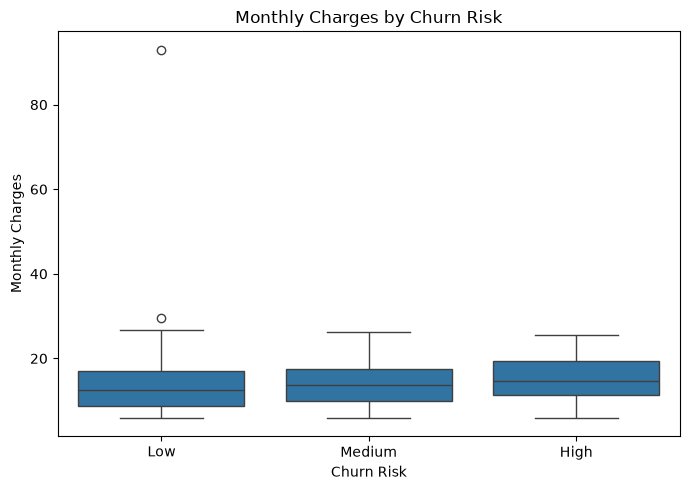

In [25]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='churn_risk', y='monthly_charges', order=['Low', 'Medium', 'High'])
plt.title('Monthly Charges by Churn Risk')
plt.xlabel('Churn Risk')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()


## 10. Business Insights

For this small sample, the analysis shows a **28.57% churn rate**. Basic has the highest observed churn rate at **60%**, followed by Standard at **22.22%** and Premium at **14.29%**. Churned customers account for **73.94** in monthly charges in the source data. These results should be treated as directional because the dataset contains only 21 customers.

The churn-score grouping contains 13 low-risk, 2 medium-risk, and 6 high-risk customers. Support records are limited to a subset of customers, so escalation patterns should be interpreted carefully rather than treated as proof of causation.

## 11. Recommendations
- Review the Basic plan experience because it has the highest observed churn in this sample.
- Prioritize high churn-score customers for retention follow-up.
- Review customers with repeated support contacts or escalations before renewal.
- Monitor churn and revenue-at-risk regularly as more customer records become available.

## Conclusion
This project combines MySQL and Python to prepare customer, subscription, and support data and turn it into a practical churn analysis. The final dataset can be reused for future retention reporting or a larger predictive analysis when more historical data is available.